In [1]:
from tqdm import tqdm
import time
import sys
import os


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader


sys.path.append(os.path.abspath(".."))
from package.SingleCharTokenizer import *
from package.TextDataset import * 
from package.GPT import * 

%load_ext autoreload
%autoreload 2

device = torch.device("cpu")

In [2]:
sliding_windows = 1

context_window = 128
batch_size = 64

d_emb = 256
nb_heads = 4
d_k = d_emb // nb_heads

nb_layers = 6

In [3]:
gpt = GPT.load("training_historic/0040.w").to(device)

In [4]:
init = "bonjour, je m'appelle chateaubriand. je suis un homme de mon temps, j'ai connu les voyages, la revolutions et les cataclysmes politiques et je pense que "

In [5]:
tokenizer = SingleCharTokenizer()
tokens = torch.tensor(tokenizer.load_tokens("../tokens.tok")).to(device)
#testing_tokens = torch.tensor(tokenizer.load_tokens("testing_tokens.tok")).to(device)



In [6]:
corpus = open("dataset/testing.txt").read()
testing_tokens = tokenizer.encode(corpus)
tokenizer.save_tokens(testing_tokens,filename = "testing_tokens.tok")

FileNotFoundError: [Errno 2] No such file or directory: 'dataset/testing.txt'

In [6]:






vocab_size = tokenizer.vocab_size
print("vocab_size : " , vocab_size)

test_dataset = TextDataset(testing_tokens,context_window=context_window,sliding_windows=sliding_windows)
print("dataset_size : " ,len(test_dataset))


loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    num_workers = 2
)

vocab_size :  65
dataset_size :  103


In [7]:
len(loader)

1

In [8]:
def compute_loss(model,loader):
    model.eval()
    
    N = len(loader)
    mean_loss = 0
    #for step in tqdm(range(nb_steps)):
    for step,(x, y) in enumerate((iter(loader))):
        x = x.to(device)
        y = y.to(device)

        logits = model(x)

        loss = F.cross_entropy(logits.view(-1, vocab_size), y.view(-1))
        mean_loss += loss/N
    return mean_loss





In [11]:





compute_loss(gpt,loader)

tensor(0.9640, grad_fn=<AddBackward0>)

In [12]:
import os


In [13]:
files =sorted( os.listdir("training_historic"))


In [14]:
print(files)

['0000.w', '0001.w', '0002.w', '0003.w', '0004.w', '0005.w', '0006.w', '0007.w', '0008.w', '0009.w', '0010.w', '0011.w', '0012.w', '0013.w', '0014.w', '0015.w', '0016.w', '0017.w', '0018.w', '0019.w', '0020.w', '0021.w', '0022.w', '0023.w', '0024.w', '0025.w', '0026.w', '0027.w', '0028.w', '0029.w', '0030.w', '0031.w', '0032.w', '0033.w', '0034.w', '0035.w', '0036.w', '0037.w', '0038.w', '0039.w', '0040.w', '0041.w', '0042.w', '0043.w', '0044.w', '0045.w', '0046.w', '0047.w', '0048.w', '0049.w', 'final.w', 'final2.w', 'final3.w']


In [18]:
losses = []
for i in tqdm(range(len(files))):
    if files[i] != "final.w" or files[i] != "final2.w" :
        
        gpt = GPT.load("training_historic/" + files[i]).to(device)
        losses.append(compute_loss(gpt,loader).item())
    else :
        print(files[i])

  0%|          | 0/53 [00:00<?, ?it/s]

100%|██████████| 53/53 [00:42<00:00,  1.24it/s]


In [48]:
losses[0].item()

4.411210536956787

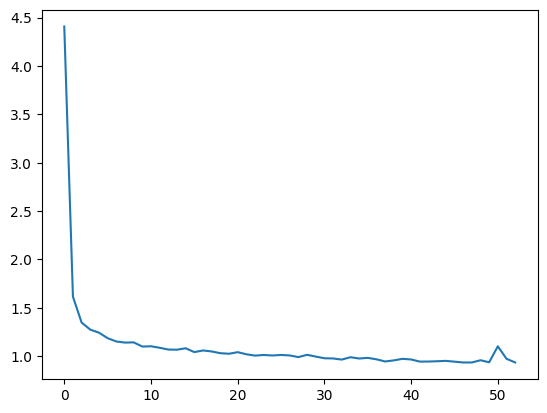

In [19]:
import matplotlib.pyplot as plt



plt.plot(losses)

In [15]:
init_tok = tokenizer.encode(init)
print(init_tok)

[37, 50, 49, 45, 50, 56, 53, 12, 2, 45, 40, 2, 48, 7, 36, 51, 51, 40, 47, 47, 40, 2, 38, 43, 36, 55, 40, 36, 56, 37, 53, 44, 36, 49, 39, 14, 2, 45, 40, 2, 54, 56, 44, 54, 2, 56, 49, 2, 43, 50, 48, 48, 40, 2, 39, 40, 2, 48, 50, 49, 2, 55, 40, 48, 51, 54, 12, 2, 45, 7, 36, 44, 2, 38, 50, 49, 49, 56, 2, 47, 40, 54, 2, 57, 50, 60, 36, 42, 40, 54, 12, 2, 47, 36, 2, 53, 40, 57, 50, 47, 56, 55, 44, 50, 49, 54, 2, 40, 55, 2, 47, 40, 54, 2, 38, 36, 55, 36, 38, 47, 60, 54, 48, 40, 54, 2, 51, 50, 47, 44, 55, 44, 52, 56, 40, 54, 2, 40, 55, 2, 45, 40, 2, 51, 40, 49, 54, 40, 2, 52, 56, 40, 2]


In [21]:

@torch.no_grad()
def generate(model, tokenizer, prompt, max_new_tokens=100, temperature=1.0,k=50):
    model.eval()

    # Encode prompt
    tokens = tokenizer.encode(prompt)
    tokens = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(device)

    for _ in range(max_new_tokens):

        # If context too long, crop to block_size
        block_size = 128
        tokens_cond = tokens[:, -block_size:]

        # Forward pass
        logits = model(tokens_cond)

        # Take last time step
        logits = logits[:, -1, :] / temperature

        # # Convert to probabilities
        # probs = F.softmax(logits, dim=-1)

        # # Sample next token
        # next_token = torch.multinomial(probs, num_samples=1)
     
        values, indices = torch.topk(logits, k)
        probs = F.softmax(values, dim=-1)
        next_token = indices.gather(-1, torch.multinomial(probs, 1))

        # Append
        tokens = torch.cat((tokens, next_token), dim=1)

    # Decode full sequence
    output = tokenizer.decode(tokens[0].tolist())
    return output

In [22]:
gpt = GPT.load("training_historic/0001.w").to(device)
out = generate(gpt,tokenizer,init,max_new_tokens=300,temperature=0.9,k=40)

In [23]:
print(out)

bonjour, je m'appelle chateaubriand. je suis un homme de mon temps, j'ai connu les voyages, la revolutions et les cataclysmes politiques et je pense que l'avaient sur la postyre de condes peuitre oie guit illuyragee ; sa repande la reditaite en : elle tracteape couche a l'ammer dire- quelques sens mouvelaientes est de la busoure, qui se nous puauve au scoloptessee on moi la fine ronte chez, en gave au ou des l'etattes a ses approcres : "
il misaire
